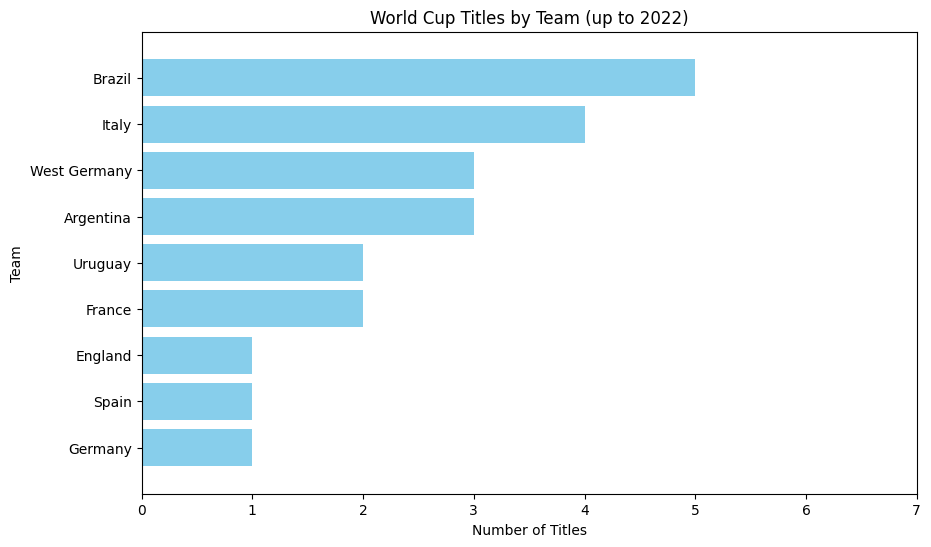

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
from IPython.display import HTML
from collections import defaultdict

# Datele: An -> Câștigător
world_cup_winners = {
    1930: 'Uruguay',
    1934: 'Italy',
    1938: 'Italy',
    1950: 'Uruguay',
    1954: 'West Germany',
    1958: 'Brazil',
    1962: 'Brazil',
    1966: 'England',
    1970: 'Brazil',
    1974: 'West Germany',
    1978: 'Argentina',
    1982: 'Italy',
    1986: 'Argentina',
    1990: 'West Germany',
    1994: 'Brazil',
    1998: 'France',
    2002: 'Brazil',
    2006: 'Italy',
    2010: 'Spain',
    2014: 'Germany',
    2018: 'France',
    2022: 'Argentina',
}

# Calculează numărul de titluri pe echipă, pe ani
years = sorted(world_cup_winners.keys())
teams = list(set(world_cup_winners.values()))
titles_by_year = defaultdict(dict)

for year in years:
    winner = world_cup_winners[year]
    for team in teams:
        titles_by_year[year][team] = titles_by_year[years[years.index(year)-1]][team] if year > years[0] else 0
    titles_by_year[year][winner] += 1

# Pregătește figura
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 7)
ax.set_ylim(-1, len(teams))
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Team')
ax.set_title('World Cup Titles by Team Over Time')

def update(year):
    ax.clear()
    ax.set_xlim(0, 7)
    ax.set_ylim(-1, len(teams))
    ax.set_xlabel('Number of Titles')
    ax.set_ylabel('Team')
    ax.set_title(f'World Cup Titles by Team (up to {year})')

    current_titles = titles_by_year[year]
    sorted_teams = sorted(current_titles.keys(), key=lambda x: current_titles[x], reverse=False)
    y_pos = range(len(sorted_teams))

    bars = ax.barh(y_pos, [current_titles[team] for team in sorted_teams], color='skyblue')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_teams)

    return bars

ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=years,
    interval=800,
    repeat=False
)
if True:
    ani.save('lines.mp4', writer="ffmpeg")
    ani.save('winners.gif', writer="ffmpeg")
    plt.show()

# plt.close()
# HTML(ani.to_jshtml())